In [6]:
import pandas as pd
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import pandas as pd
from scipy.stats import chi2_contingency

import allel

In [2]:
snp_origin_bio1 = pd.read_csv('../key_files/snp_origin_bio1_grenenetvcf.csv')

In [3]:
snp_origin_bio1['id'] = snp_origin_bio1['chrom'].astype(str) + '_' + snp_origin_bio1['pos'].astype(str) 

In [4]:
results = [i for i in os.listdir('binom_reg/') if '.csv' in i]

sign_results = [i for i in os.listdir('binom_reg/') if 'sign' in i]

sites = pd.Series(sign_results).str.split('_').str[-1].str.replace('.csv', '').astype(int).reset_index()

sites.columns = ['ign', 'site']

#clim_sites_during_exp = pd.read_csv('/carnegie/nobackup/scratch/tbellagio/grene/data/bioclimvars_experimental_sites_era5.csv')
clim_sites_during_exp = pd.read_csv('../key_files/bioclimvars_experimental_sites_era5.csv')

clim_sites_during_exp = clim_sites_during_exp[['site', 'bio1']]

clim_sites_during_exp = clim_sites_during_exp.merge(sites['site'])

clim_sites_during_exp_ordered = clim_sites_during_exp.sort_values('bio1')

unique_sites = clim_sites_during_exp_ordered['site'].values

In [ ]:
for i, (ax, site_value) in enumerate(zip(axes, unique_sites)):
    print(site_value)
    site = pd.read_csv(f'binom_reg/sign_site_{site_value}.csv')
    #if len(site) > 10000:
    #    site = site.sort_values('p_value').head(10000
    # Merge with snp_origin_bio1 DataFrame
    site = site.merge(snp_origin_bio1, on='id')
    
    # Create a scatter plot for each result on its corresponding subplot

In [9]:
site_value = 4

In [7]:
snp_pruned = allel.read_vcf('../key_files/greneNet_final_v1.1_LDpruned.recode.vcf')

snp_pruned = snp_pruned['variants/ID']

In [8]:
results = {}
for site_value in unique_sites:
    
    df = pd.read_csv(f'binom_reg/sign_site_{site_value}.csv')
    df = df.merge(snp_origin_bio1, on='id')

    df = df[df['id'].isin(snp_pruned)].reset_index(drop=True)
    
    # Create binary variables for the sign of slope and snp_origin_bio1
    df['snp_origin_sign'] = (df['snp_origin_bio1'] > 0).astype(int)
    df['slope_sign'] = (df['slope'] > 0).astype(int)
    
    # Construct the contingency table
    contingency_table = pd.crosstab(df['snp_origin_sign'], df['slope_sign'])
    
    # Perform the chi-squared test
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency_table)
    
    results[site_value] = [chi2_stat, p_value]

In [9]:
results = pd.DataFrame(results).T

In [10]:
results.columns = ['chi2_stat', 'p_value']

In [14]:
results = results.reset_index()

In [17]:
results.columns = ['site', 'chi2_stat', 'p_value']

In [18]:
results.to_csv('test_enrichment_snp_origin_ld_prun.csv',index=None)

In [19]:
results

,site,chi2_stat,p_value
0,24,7.857587,5.060789e-03
1,27,0.000000,1.000000e+00
2,48,0.000000,1.000000e+00
3,1,19.852339,8.366029e-06
4,42,230.578045,4.459450e-52
5,46,423.640483,3.936045e-94
6,25,18.680116,1.545861e-05
7,55,784.222491,1.453510e-172
8,49,477.897628,6.126568e-106
9,52,0.106110,7.446169e-01


In [16]:
table1 = pd.crosstab(site[f'slope'], site[f'snp_origin_bio1'])


KeyboardInterrupt



In [ ]:
table1

<Axes: xlabel='snp_origin_bio1', ylabel='slope'>

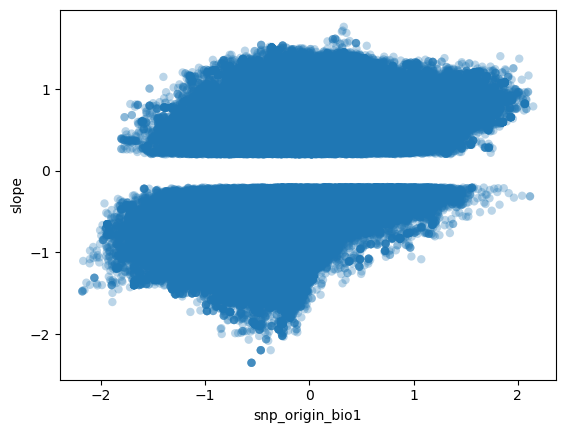

In [14]:
import pandas as pd
import numpy as np
from itertools import combinations
from scipy.stats import chi2_contingency

# Array of unique sites

# Placeholder for results
results = {}

# Loop through all unique pairwise combinations of sites
for site_value in unique_sites:
    # Load data for first site

    site1 = pd.read_csv(f'binom_reg/site_{site_value_1}.csv')
    
    th1 = 0.05 / len(site1)
    site1['sign'] = site1['p_value'] < th1
    site1.columns = [f'slope_site{site_value_1}', f'p_value{site_value_1}', 'id', f'sign_{site_value_1}']
    

    
    # Merge datasets on 'id'
    df = site.merge(snp_origin_bio1, on='id')
    
    # Contingency table for Pleiotropy vs Conditional Neutrality
    table1 = pd.crosstab(df[f'sign_{site_value_1}'], df[f'sign_{site_value_2}'])
    chi1, p_value1, _, _ = chi2_contingency(table1)

    # For antagonistic vs synergistic pleiotropy, filter for selected in both sites
    df_both_selected = df[(df[f'sign_{site_value_1}'] == True) & (df[f'sign_{site_value_2}'] == True)]

    if df_both_selected.empty: 
        results[(site_value_1, site_value_2)] = {'Chi_square_PvC': chi1, 'P_value_PvC': p_value1, 'Chi_square_SvA': np.nan, 'P_value_SvA': np.nan}

    else: 
        df_both_selected['direction_site1'] = np.where(df_both_selected[f'slope_site{site_value_1}'] > 0, 'Positive', 'Negative')
        df_both_selected['direction_site2'] = np.where(df_both_selected[f'slope_site{site_value_2}'] > 0, 'Positive', 'Negative')
    
        # Contingency table for Synergistic vs Antagonistic Pleiotropy
        table2 = pd.crosstab(df_both_selected['direction_site1'], df_both_selected['direction_site2'])
        chi2, p_value2, _, _ = chi2_contingency(table2)
    
    # Store results


In [5]:
results_sign = [i for i in os.listdir('results_persite') if 'sign' in i]

In [6]:
d_sites = [1, 4, 9, 10, 11, 32, 42, 43, 45, 46, 54]

1
4
9
10
11
32


/tmp/ipykernel_1660458/2440636843.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_1660458/2440636843.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


42


/tmp/ipykernel_1660458/2440636843.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


43
45
46
54


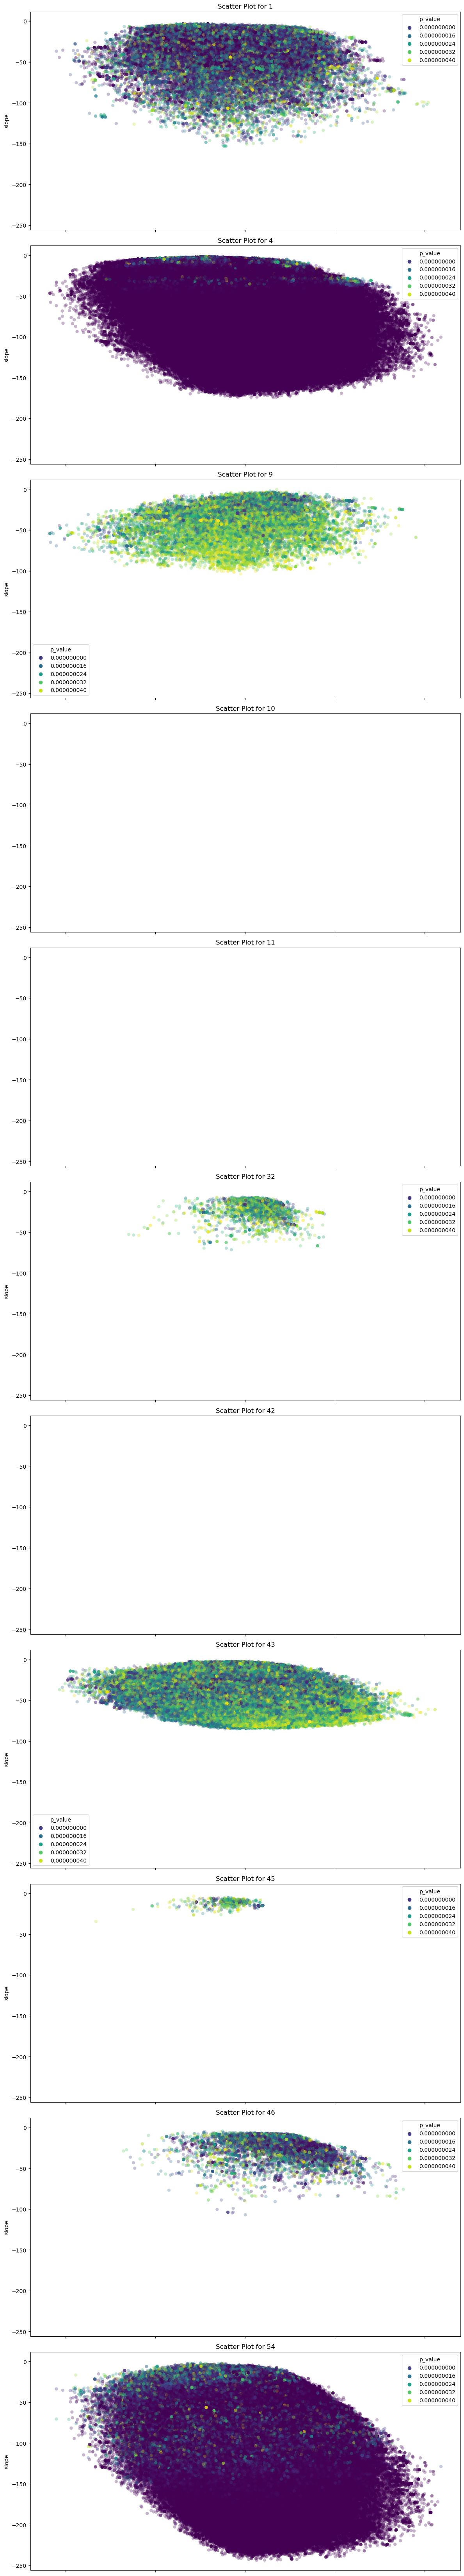

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming results_sign is a list of filenames and snp_origin_bio1 is a DataFrame
n_plots = len(results_sign)  # Number of subplots

# Create a grid of subplots with shared x and y axes, and adjust for empty plots
fig, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(12, 6 * n_plots), sharex=True, sharey=True)

# If there is only one plot, `axes` will not be an array, so we ensure it's treated as one
if n_plots == 1:
    axes = [axes]

# Loop through results_sign and plot each site
for i, (ax, site_number) in enumerate(zip(axes, d_sites)):
    site = pd.read_csv(f'results_persite/sign_site_{site_number}.csv')
    print(site_number)
    
    # Merge with snp_origin_bio1 DataFrame
    site = site.merge(snp_origin_bio1, on='id')
    
    # Create a scatter plot for each result on its corresponding subplot
    sns.scatterplot(
        data=site,
        x='snp_origin_bio1',
        y='slope',
        hue='p_value',
        palette="viridis",
        edgecolor="none",
        alpha=0.3,
        ax=ax
    )
    
    # Set title for each subplot
    ax.set_title(f"Scatter Plot for {site_number}")

# If there are more axes (subplots) than data, hide the empty ones
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show the figure
plt.tight_layout()
plt.show()


In [141]:
i_sites = [13, 27, 52, 53]

13
27
52
53


/tmp/ipykernel_1539584/550138795.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_1539584/550138795.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_1539584/550138795.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/tmp/ipykernel_1539584/550138795.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


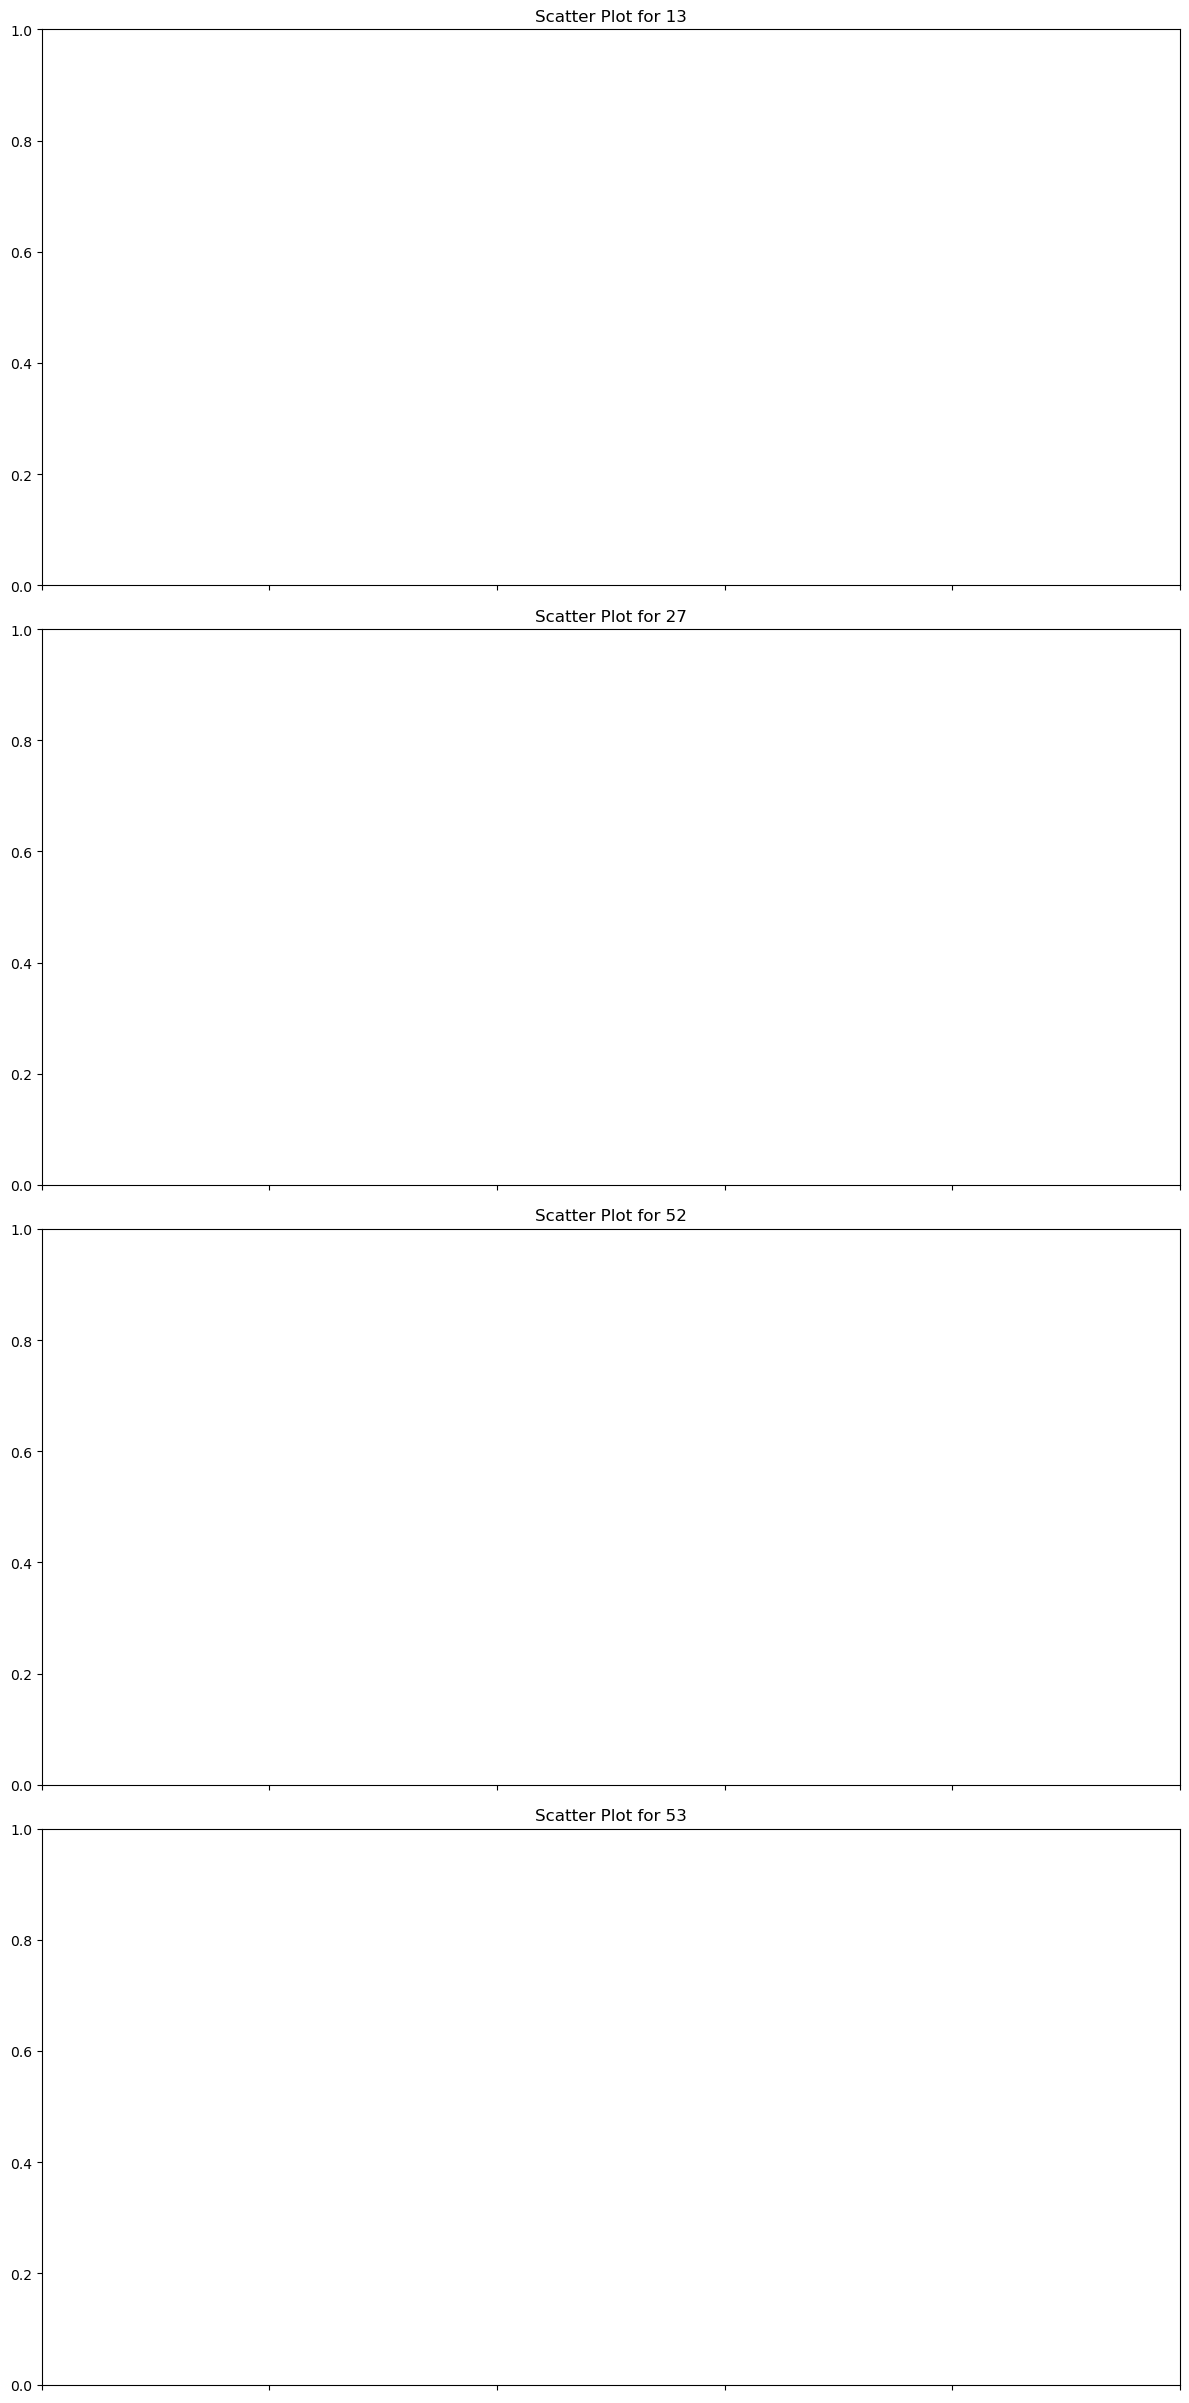

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming results_sign is a list of filenames and snp_origin_bio1 is a DataFrame
n_plots = len(results_sign)  # Number of subplots

# Create a grid of subplots with shared x and y axes, and adjust for empty plots
fig, axes = plt.subplots(nrows=n_plots, ncols=1, figsize=(12, 6 * n_plots), sharex=True, sharey=True)

# If there is only one plot, `axes` will not be an array, so we ensure it's treated as one
if n_plots == 1:
    axes = [axes]

# Loop through results_sign and plot each site
for i, (ax, site_number) in enumerate(zip(axes, i_sites)):
    site = pd.read_csv(f'results_persite/sign_site_{site_number}.csv')
    print(site_number)
    
    # Merge with snp_origin_bio1 DataFrame
    site = site.merge(snp_origin_bio1, on='id')
    
    # Create a scatter plot for each result on its corresponding subplot
    sns.scatterplot(
        data=site,
        x='snp_origin_bio1',
        y='slope',
        hue='p_value',
        palette="viridis",
        edgecolor="none",
        alpha=0.3,
        ax=ax
    )
    
    # Set title for each subplot
    ax.set_title(f"Scatter Plot for {site_number}")

# If there are more axes (subplots) than data, hide the empty ones
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout and show the figure
plt.tight_layout()
plt.show()


In [21]:
site_4 = pd.read_csv('results_persite/sign_site_4.csv')

In [22]:
site_4 = site_4.merge(snp_origin_bio1, on ='id')

In [30]:
site_52 = pd.read_csv('results_persite/site_52.csv')

In [43]:
sign_site_52 = site_52.sort_values('p_value').head(100000)

<Axes: xlabel='slope', ylabel='Count'>

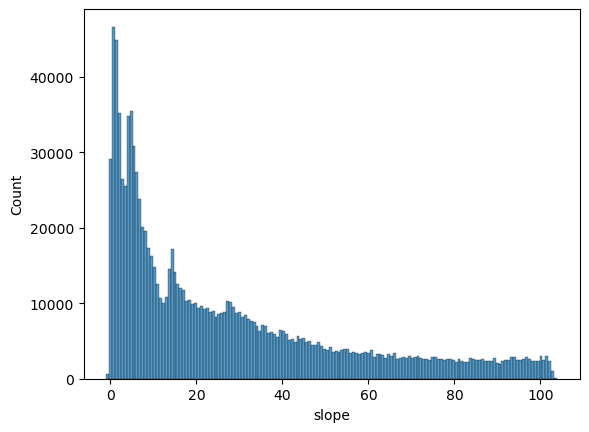

In [32]:
sns.histplot(site_52['slope'])

<Axes: xlabel='p_value', ylabel='Count'>

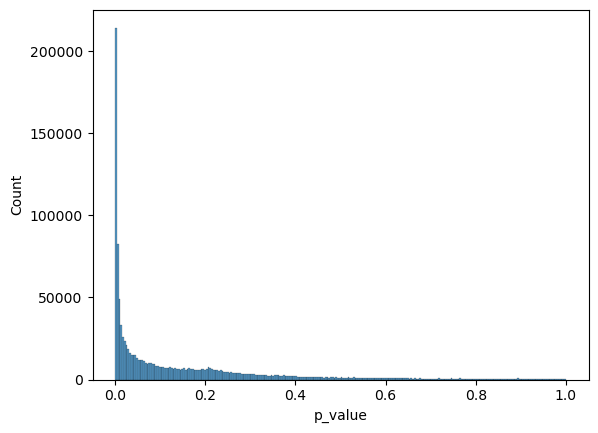

In [33]:
sns.histplot(site_52['p_value'])

In [35]:
site_52 = site_52.merge(snp_origin_bio1, on ='id')

In [36]:
site_52

,slope,p_value,id,chrom,pos,snp_origin_bio1
0,40.878389,0.019837,1_346,1,346,5.149026
1,8.295533,0.218462,1_353,1,353,1.413023
2,10.535089,0.240647,1_363,1,363,1.734019
3,0.786764,0.467767,1_395,1,395,1.604329
4,0.786764,0.467767,1_396,1,396,1.604329
...,...,...,...,...,...,...
1147887,89.982090,0.001031,5_26975078,5,26975078,15.907648
1147888,1.253752,0.588244,5_26975121,5,26975121,1.434812
1147889,1.253752,0.588244,5_26975148,5,26975148,1.434812
1147890,34.184139,0.006381,5_26975272,5,26975272,7.863781


In [19]:
site_4

,slope,p_value,id,chrom,pos,snp_origin_bio1
0,-46.014055,6.298208e-14,1_346,1,346,5.149026
1,-20.027665,3.466740e-12,1_353,1,353,1.413023
2,-12.956297,3.971168e-10,1_363,1,363,1.734019
3,-10.823376,1.105953e-03,1_395,1,395,1.604329
4,-10.823376,1.105953e-03,1_396,1,396,1.604329
...,...,...,...,...,...,...
1147887,-133.254249,1.943622e-14,5_26975078,5,26975078,15.907648
1147888,-15.927397,2.474483e-12,5_26975121,5,26975121,1.434812
1147889,-15.927397,2.474483e-12,5_26975148,5,26975148,1.434812
1147890,-77.491262,1.973962e-13,5_26975272,5,26975272,7.863781


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Assuming snp_origin_beta_binomial_reg is your DataFrame with SNP data
# Calculate the KDE for 'snp_origin_bio1' and 'slope'
#values = np.vstack([snp_origin_beta_lfmm_s["snp_origin_bio1"], snp_origin_beta_lfmm_s["bio1"]])
#kernel = stats.gaussian_kde(values)(values)

# Create a scatter plot using density for color
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=sign_site_52,
    x='snp_origin_bio1',
    y='slope',
    hue='p_value',  # Use the density as color
    palette="viridis",  # Color mapping
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.3,  # Set transparency
    ax=ax
)

# Add a color bar to show the density scale
#norm = plt.Normalize(kernel.min(), kernel.max())
#sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
#sm.set_array([])
#fig.colorbar(sm, ax=ax, label='Density')
plt.ylabel('Slope time')
# Display the plot
plt.show()

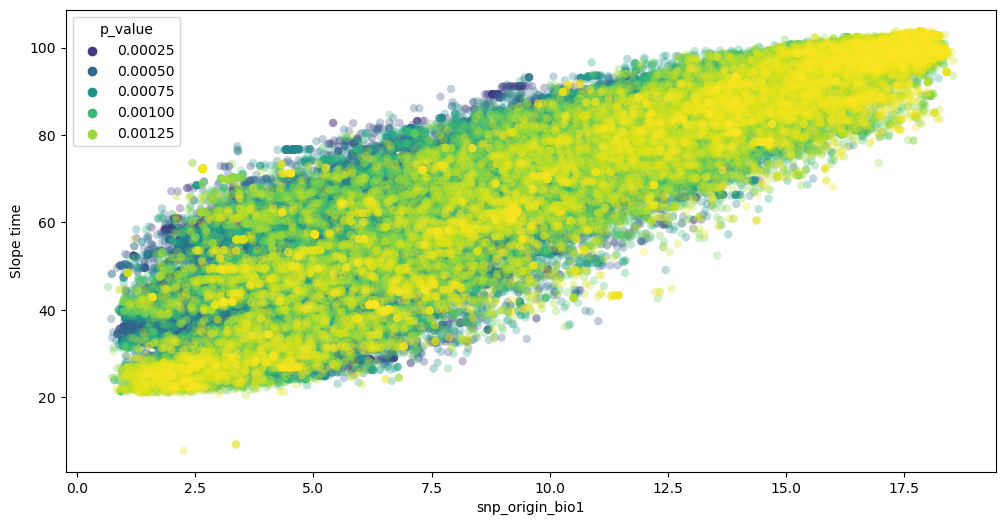

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Assuming snp_origin_beta_binomial_reg is your DataFrame with SNP data
# Calculate the KDE for 'snp_origin_bio1' and 'slope'
#values = np.vstack([snp_origin_beta_lfmm_s["snp_origin_bio1"], snp_origin_beta_lfmm_s["bio1"]])
#kernel = stats.gaussian_kde(values)(values)

# Create a scatter plot using density for color
fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=sign_site_52,
    x='snp_origin_bio1',
    y='slope',
    hue='p_value',  # Use the density as color
    palette="viridis",  # Color mapping
    edgecolor="none",  # Remove white edge around the dots
    alpha=0.3,  # Set transparency
    ax=ax
)

# Add a color bar to show the density scale
#norm = plt.Normalize(kernel.min(), kernel.max())
#sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
#sm.set_array([])
#fig.colorbar(sm, ax=ax, label='Density')
plt.ylabel('Slope time')
# Display the plot
plt.show()

,chrom,pos,snp_origin_bio1
0,1,291,1.249206
1,1,346,5.149026
2,1,349,0.207937
3,1,352,0.395563
4,1,353,1.413023
...,...,...,...
3235475,5,26975208,0.238672
3235476,5,26975215,0.241486
3235477,5,26975267,0.087590
3235478,5,26975272,7.863781


In [89]:
flowers = pd.read_csv('../key_files/merged_sample_table.csv')
num_flowers_map = flowers.set_index('sample_name')['total_flower_counts'].to_dict()

In [90]:
flowers_site = flowers.pivot_table(index=['site'], columns = 'generation', values = 'total_flower_counts', aggfunc=np.sum)

In [91]:
flowers_site = flowers_site.dropna(thresh=2)

In [107]:
flowers_site

generation,1,2,3
site,,,
1,2622.0,1941.0,620.0
2,395.0,30.0,NaN
4,2400.0,723.0,342.0
5,2323.0,788.0,3199.0
6,2320.0,549.0,NaN
9,1484.0,14.0,199.0
10,194.0,19.0,12.0
11,140.0,26.0,69.0
12,211.0,132.0,NaN


In [121]:
# Check where generation 2 > generation 1
increase_gen_1_to_3 = flowers_site[3] > flowers_site[1]

increase_df = pd.DataFrame()
#increase_df['site'] = flowers_site.index.values
increase_df['Increase from Gen 1 to Gen 3'] = increase_gen_1_to_3#.astype(float)
#increase_df['Increase from Gen 2 to Gen 3'] = increase_gen_2_to_3#.astype(float)

i_g13 = increase_df['Increase from Gen 1 to Gen 3'].sort_values()[increase_df['Increase from Gen 1 to Gen 3'].sort_values() == True].index.values

# Check where generation 2 > generation 1
increase_gen_1_to_2 = flowers_site[2] > flowers_site[1]
increase_df = pd.DataFrame()
#increase_df['site'] = flowers_site.index.values
increase_df['Increase from Gen 1 to Gen 2'] = increase_gen_1_to_2#.astype(float)
#increase_df['Increase from Gen 2 to Gen 3'] = increase_gen_2_to_3#.astype(float)

i_g12 = increase_df['Increase from Gen 1 to Gen 2'].sort_values()[increase_df['Increase from Gen 1 to Gen 2'].sort_values() == True].index.values


In [122]:
i_g12

array([27, 13, 33, 52, 53, 57])

In [123]:
i_g13

array([13, 27, 55,  5, 48, 52, 53, 28])

In [124]:
set(i_g12).intersection(set(i_g13))

{13, 27, 52, 53}

In [125]:
# Check where generation 2 > generation 1
increase_gen_1_to_3 = flowers_site[3] < flowers_site[1]

increase_df = pd.DataFrame()
#increase_df['site'] = flowers_site.index.values
increase_df['Increase from Gen 1 to Gen 3'] = increase_gen_1_to_3#.astype(float)
#increase_df['Increase from Gen 2 to Gen 3'] = increase_gen_2_to_3#.astype(float)

d_g13 = increase_df['Increase from Gen 1 to Gen 3'].sort_values()[increase_df['Increase from Gen 1 to Gen 3'].sort_values() == True].index.values
# Check where generation 2 > generation 1
increase_gen_1_to_2 = flowers_site[2] < flowers_site[1]
increase_df = pd.DataFrame()
#increase_df['site'] = flowers_site.index.values
increase_df['Increase from Gen 1 to Gen 2'] = increase_gen_1_to_2#.astype(float)
#increase_df['Increase from Gen 2 to Gen 3'] = increase_gen_2_to_3#.astype(float)

d_g12 = increase_df['Increase from Gen 1 to Gen 2'].sort_values()[increase_df['Increase from Gen 1 to Gen 2'].sort_values() == True].index.values


In [126]:
d_g12

array([54, 49, 46, 45, 43, 42, 32,  1, 25, 24, 12, 11, 10,  9,  6,  5,  4,
        2, 55, 28])

In [127]:
d_g13

array([54, 46, 45,  1, 42, 32, 11, 10,  9,  4, 43, 57])

In [128]:
set(d_g12).intersection(set(d_g13))

{1, 4, 9, 10, 11, 32, 42, 43, 45, 46, 54}

In [36]:
#increase_df = increase_df.set_index('site')

In [37]:
#increase_df = increase_df.dropna(how='all')

site
1     False
54    False
49    False
46    False
45    False
43    False
42    False
33    False
32    False
25    False
57    False
12    False
11    False
10    False
9     False
6     False
4     False
2     False
24    False
13     True
27     True
55     True
5      True
48     True
52     True
53     True
28     True
Name: Increase from Gen 1 to Gen 3, dtype: bool

<Axes: ylabel='site'>

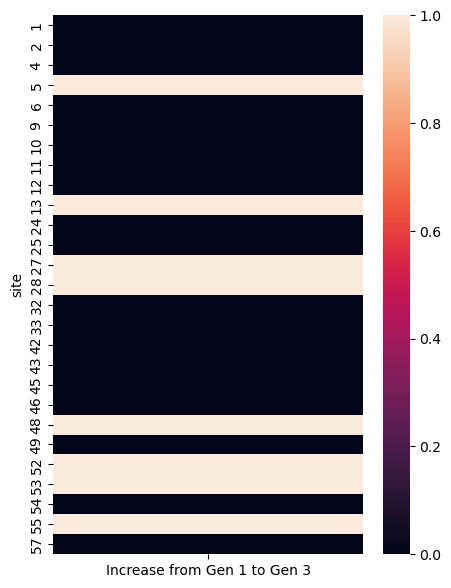

In [47]:
plt.figure(figsize=(5, 7))
sns.heatmap(increase_df)

In [14]:
flowers_site.shape[1]

3

In [17]:
flowers_site = flowers_site.dropna(thresh=2)

In [51]:
increase_df

,Increase from Gen 1 to Gen 3
site,
1,False
2,False
4,False
5,True
6,False
9,False
10,False
11,False
12,False


In [52]:
mask = np.ones(flowers_site.shape, dtype=bool)

# Set the mask to False only for the 3rd column (i.e., apply transparency only there)
mask[:, 2] = increase_df.iloc[:, -1] 

In [56]:
mask = mask == False

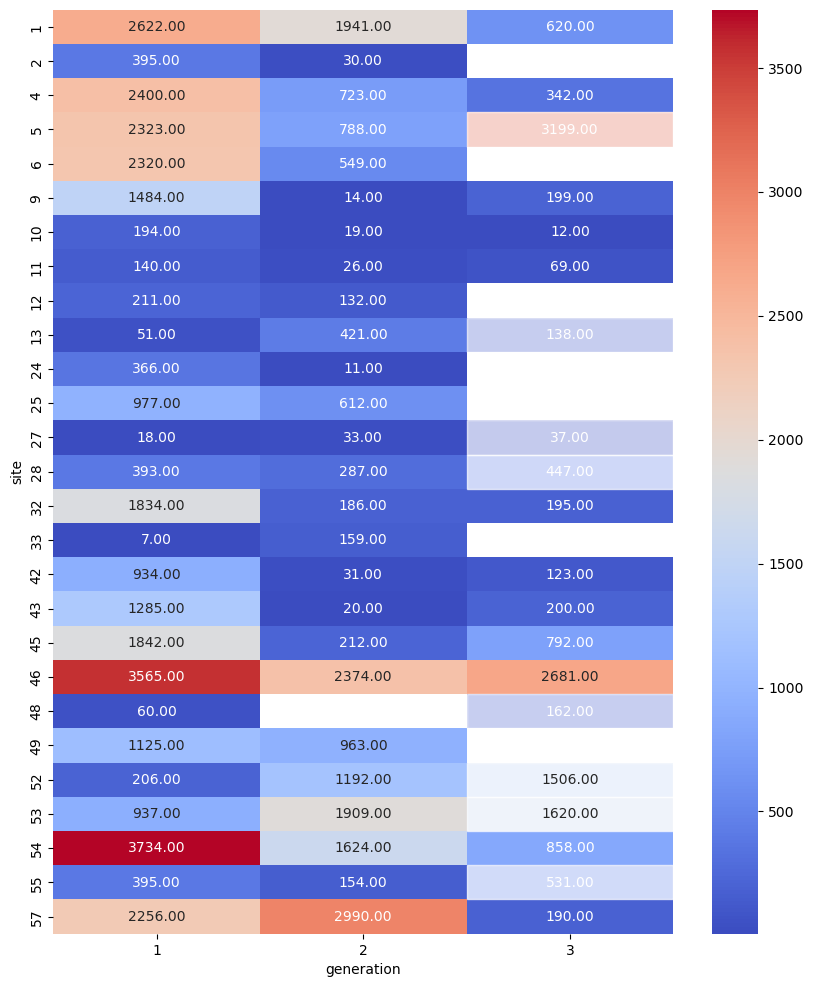

In [60]:
plt.figure(figsize=(10, 12))
sns.heatmap(flowers_site, annot=True, fmt=".2f",  cmap="coolwarm", cbar=True)
# Apply transparency to the 3rd column based on your mask
for i in range(flowers_site.shape[0]):  # Iterate over the rows
    if increase_df.iloc[i, -1]:  # Check if the condition is True for transparency
        plt.gca().add_patch(plt.Rectangle((2, i), 1, 1, fill=True, color='white', alpha=0.7))  # Slightly transparent


In [16]:
## generate the allale counts
num_flowers_map = flowers.set_index('sample_name')['total_flower_counts'].to_dict()

allele_counts = {}
for i in merged_hapFIRE_allele_frequency.columns:
    num_flowers = num_flowers_map[i]
    allele_counts[i] = merged_hapFIRE_allele_frequency[i] * num_flowers * 2

NameError: name 'merged_hapFIRE_allele_frequency' is not defined